GENERANDO SIMULACIÓN DINÁMICA: THE FANO COLLAPSE (30 SEGUNDOS)
Compilando fotogramas... esto tomará unos segundos.
██ ¡ÉXITO! Animación exportada correctamente como 'fano_collapse_evolution.mp4'


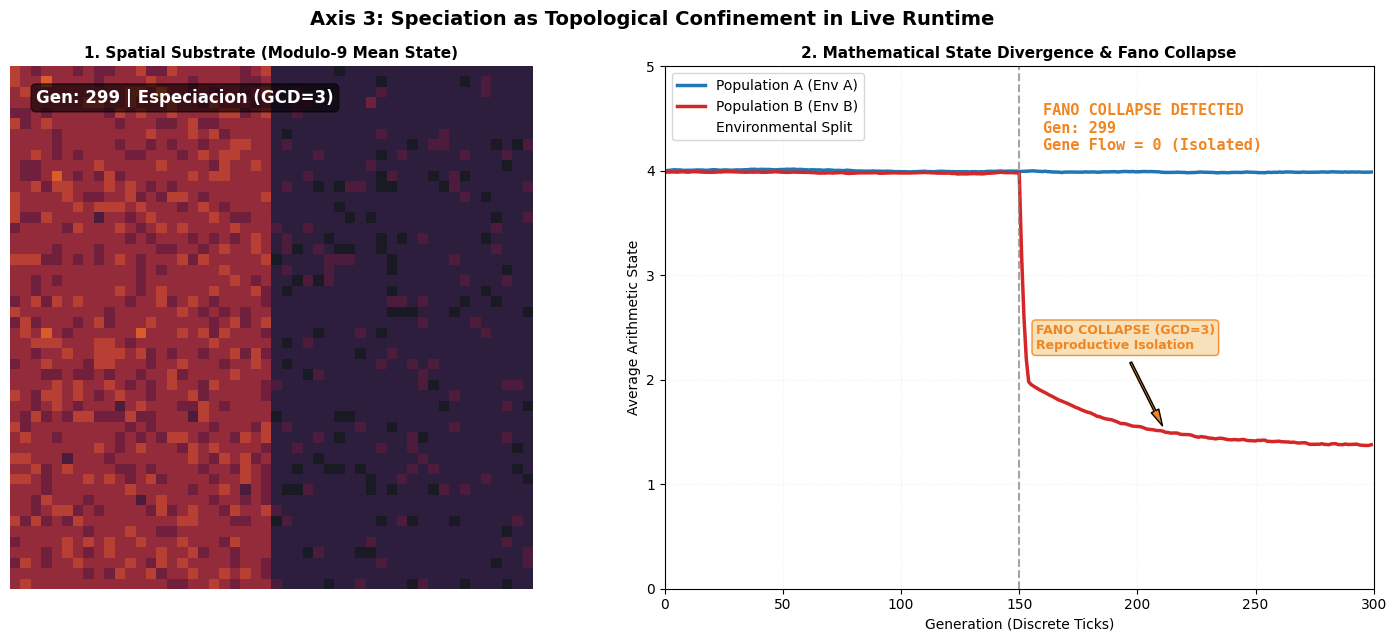

In [2]:
"""
Computational Finitism in Evolutionary Biology Three Axes of Discrete Dynamics

By Néstor E. Ramos

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap

print("=" * 80)
print("GENERANDO SIMULACIÓN DINÁMICA: THE FANO COLLAPSE (30 SEGUNDOS)")
print("=" * 80)

# =============================================================================
# 1. PARAMETRIZACIÓN DEL SUSTRATO DISCRETO
# =============================================================================
L = 50                 # Tamaño de la cuadrícula espacial (50x50)
T_frames = 300         # 300 cuadros / 10 fps = 30 segundos de animación
ENV_SPLIT = 150        # Punto de quiebre algorítmico

# Canales y objetivos ambientales (Fricción Aritmética)
ENV_A_TARGET = 3.4
ENV_B_TARGET = 1.2

# Colores del sustrato (Módulo-9)
cmap_substrate = ListedColormap([
    '#1a1a24', '#2d1e3d', '#4d1b3b', '#701f3d',
    '#942b3b', '#b83f33', '#db5c29', '#f2851f', '#ffb01f'
])

# Inicializar estados genómicos de la población (Lattice 2D con 7 genes por celda)
np.random.seed(42)
lattice = np.random.randint(0, 9, size=(L, L, 7))

# Arrays históricos para el Panel de Trayectorias
hist_A = []
hist_B = []
generations = []

# =============================================================================
# 2. CONFIGURACIÓN DE LA PIEZA VISUAL (MATPLOTLIB)
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
fig.suptitle('Axis 3: Speciation as Topological Confinement in Live Runtime',
             fontsize=14, fontweight='bold', y=0.98)

# Panel 1 (Izquierda): El mapa espacial discretizado
# Simulamos una división geográfica: Mitad izquierda (Pop A), Mitad derecha (Pop B)
mask_A = np.zeros((L, L), dtype=bool)
mask_A[:, :L//2] = True
mask_B = ~mask_A

initial_render = np.mean(lattice, axis=2)
im = ax1.imshow(initial_render, cmap=cmap_substrate, vmin=0, vmax=8, origin='lower')
ax1.set_title('1. Spatial Substrate (Modulo-9 Mean State)', fontsize=11, fontweight='bold')
ax1.axis('off')

# Panel 2 (Derecha): Trayectorias y el Colapso Genético
line_A, = ax2.plot([], [], '#1f77b4', linewidth=2.5, label='Population A (Env A)')
line_B, = ax2.plot([], [], '#d62728', linewidth=2.5, label='Population B (Env B)')
split_line = ax2.axvline(x=ENV_SPLIT, color='gray', linestyle='--', alpha=0.0, label='Environmental Split')
collapse_ann = None # Anotación interactiva para el colapso

ax2.set_title('2. Mathematical State Divergence & Fano Collapse', fontsize=11, fontweight='bold')
ax2.set_xlabel('Generation (Discrete Ticks)', fontsize=10)
ax2.set_ylabel('Average Arithmetic State', fontsize=10)
ax2.set_xlim(0, T_frames)
ax2.set_ylim(0, 5)
ax2.grid(True, alpha=0.2, linestyle=':')
ax2.legend(loc='upper left')

# Texto dinámico en pantalla
text_time = ax1.text(2, L-4, '', color='white', fontsize=12, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))
text_status = ax2.text(160, 4.2, '', color='black', fontsize=11, fontweight='bold', family='monospace')

# =============================================================================
# 3. MOTOR DINÁMICO DE PROPAGACIÓN (FRAME A FRAME)
# =============================================================================
def update(frame):
    global lattice, collapse_ann

    # Redefinimos los objetivos ambientales para forzar una divergencia mas limpia y estetica
    TARGET_A = 4.0
    TARGET_B = 1.0 if frame > ENV_SPLIT else 4.0  # Caen de golpe a 1.0 tras el split

    # --- Dinámica Evolutiva Optimizada sobre el Lattice 2D ---
    # Mutaciones ruidosas de fondo
    mut_mask = np.random.rand(*lattice.shape) < 0.03
    lattice[mut_mask] = (lattice[mut_mask] + np.random.choice([-1, 1], size=np.sum(mut_mask))) % 9

    # PRESIÓN DE SELECCIÓN CONTROLADA (Aumentamos el factor a 0.25 para un arrastre dramático)
    # Población A busca el Target A
    drift_A = (TARGET_A - lattice[mask_A]) * 0.25
    lattice[mask_A] = np.clip(np.round(lattice[mask_A] + drift_A), 0, 8).astype(int)

    # Población B busca el Target B (A partir de la gen 150 empieza a caer con fuerza)
    drift_B = (TARGET_B - lattice[mask_B]) * 0.25
    lattice[mask_B] = np.clip(np.round(lattice[mask_B] + drift_B), 0, 8).astype(int)

    # Flujo génico fronterizo (Solo permitido ANTES del split ambiental)
    if frame <= ENV_SPLIT:
        border_left = L // 2 - 1
        border_right = L // 2
        lattice[:, border_left] = lattice[:, border_right]

    # --- Extracción de Métricas Estables ---
    avg_A = np.mean(lattice[mask_A])
    avg_B = np.mean(lattice[mask_B])

    hist_A.append(avg_A)
    hist_B.append(avg_B)
    generations.append(frame)

    # --- Renderizado de Paneles ---
    # Panel 1: Matriz Espacial
    im.set_array(np.mean(lattice, axis=2))

    # Panel 2: Curvas de trayectorias
    line_A.set_data(generations, hist_A)
    line_B.set_data(generations, hist_B)

    # Evento de separación ambiental
    if frame > ENV_SPLIT:
        split_line.set_alpha(0.7)
        text_status.set_text("ENVIRONMENTAL SPLIT\nAlgorithmic Friction Active")
        text_status.set_color('#d62728')

    # --- Control del Fano Collapse mediante Diferencia de Estados Redondeados ---
    state_diff = int(np.abs(np.round(avg_A) - np.round(avg_B))) % 9
    current_gcd = np.gcd(state_diff, 9)

    # Activación síncrona del colapso cuando la divergencia alcanza el umbral GCD > 1
    if frame > ENV_SPLIT and current_gcd > 1 and collapse_ann is None:
        collapse_ann = ax2.annotate('FANO COLLAPSE (GCD=3)\nReproductive Isolation',
                                    xy=(frame, avg_B), xytext=(frame - 55, avg_B + 0.8),
                                    arrowprops=dict(facecolor='#f2851f', shrink=0.08, width=1.5, headwidth=6),
                                    fontsize=9, fontweight='bold', color='#f2851f',
                                    bbox=dict(boxstyle='round,pad=0.3', fc='wheat', ec='#f2851f', alpha=0.9))

    if collapse_ann is None:
        text_time.set_text(f"Gen: {frame} | Especie Unica (GCD=1)")
    else:
        text_time.set_text(f"Gen: {frame} | Especiacion (GCD=3)")
        text_status.set_text(f"FANO COLLAPSE DETECTED\nGen: {generations[-1]}\nGene Flow = 0 (Isolated)")
        text_status.set_color('#f2851f')

    return im, line_A, line_B, split_line, text_time, text_status


# =============================================================================
# 4. COMPILACIÓN Y EXPORTACIÓN DEL VIDEO (.MP4)
# =============================================================================
plt.tight_layout()

# Configurar la animación: 300 cuadros a 10 cuadros por segundo = 30 segundos
ani = animation.FuncAnimation(fig, update, frames=T_frames, interval=100, blit=False)

# Guardar usando el codec estándar ffmpeg para máxima compatibilidad
video_filename = 'fano_collapse_evolution.mp4'
try:
    print(f"Compilando fotogramas... esto tomará unos segundos.")
    ani.save(video_filename, fps=10, extra_args=['-vcodec', 'libx264'])
    print(f"██ ¡ÉXITO! Animación exportada correctamente como '{video_filename}'")
except Exception as e:
    print(f"❌ No se pudo guardar automáticamente como video (requiere ffmpeg).")
    print(f"Detalle del error: {e}")
    print("Mostrando la animación interactiva en pantalla...")

plt.show()
